The following result is obtained when  : 

Desired Position : amp. = 12.57 rad, freq = 0.2

Load : amp. = 1 N.m, ferq = 0.5

Desired Omega : amp. = 3.77 rad/s, frq. = 0.2





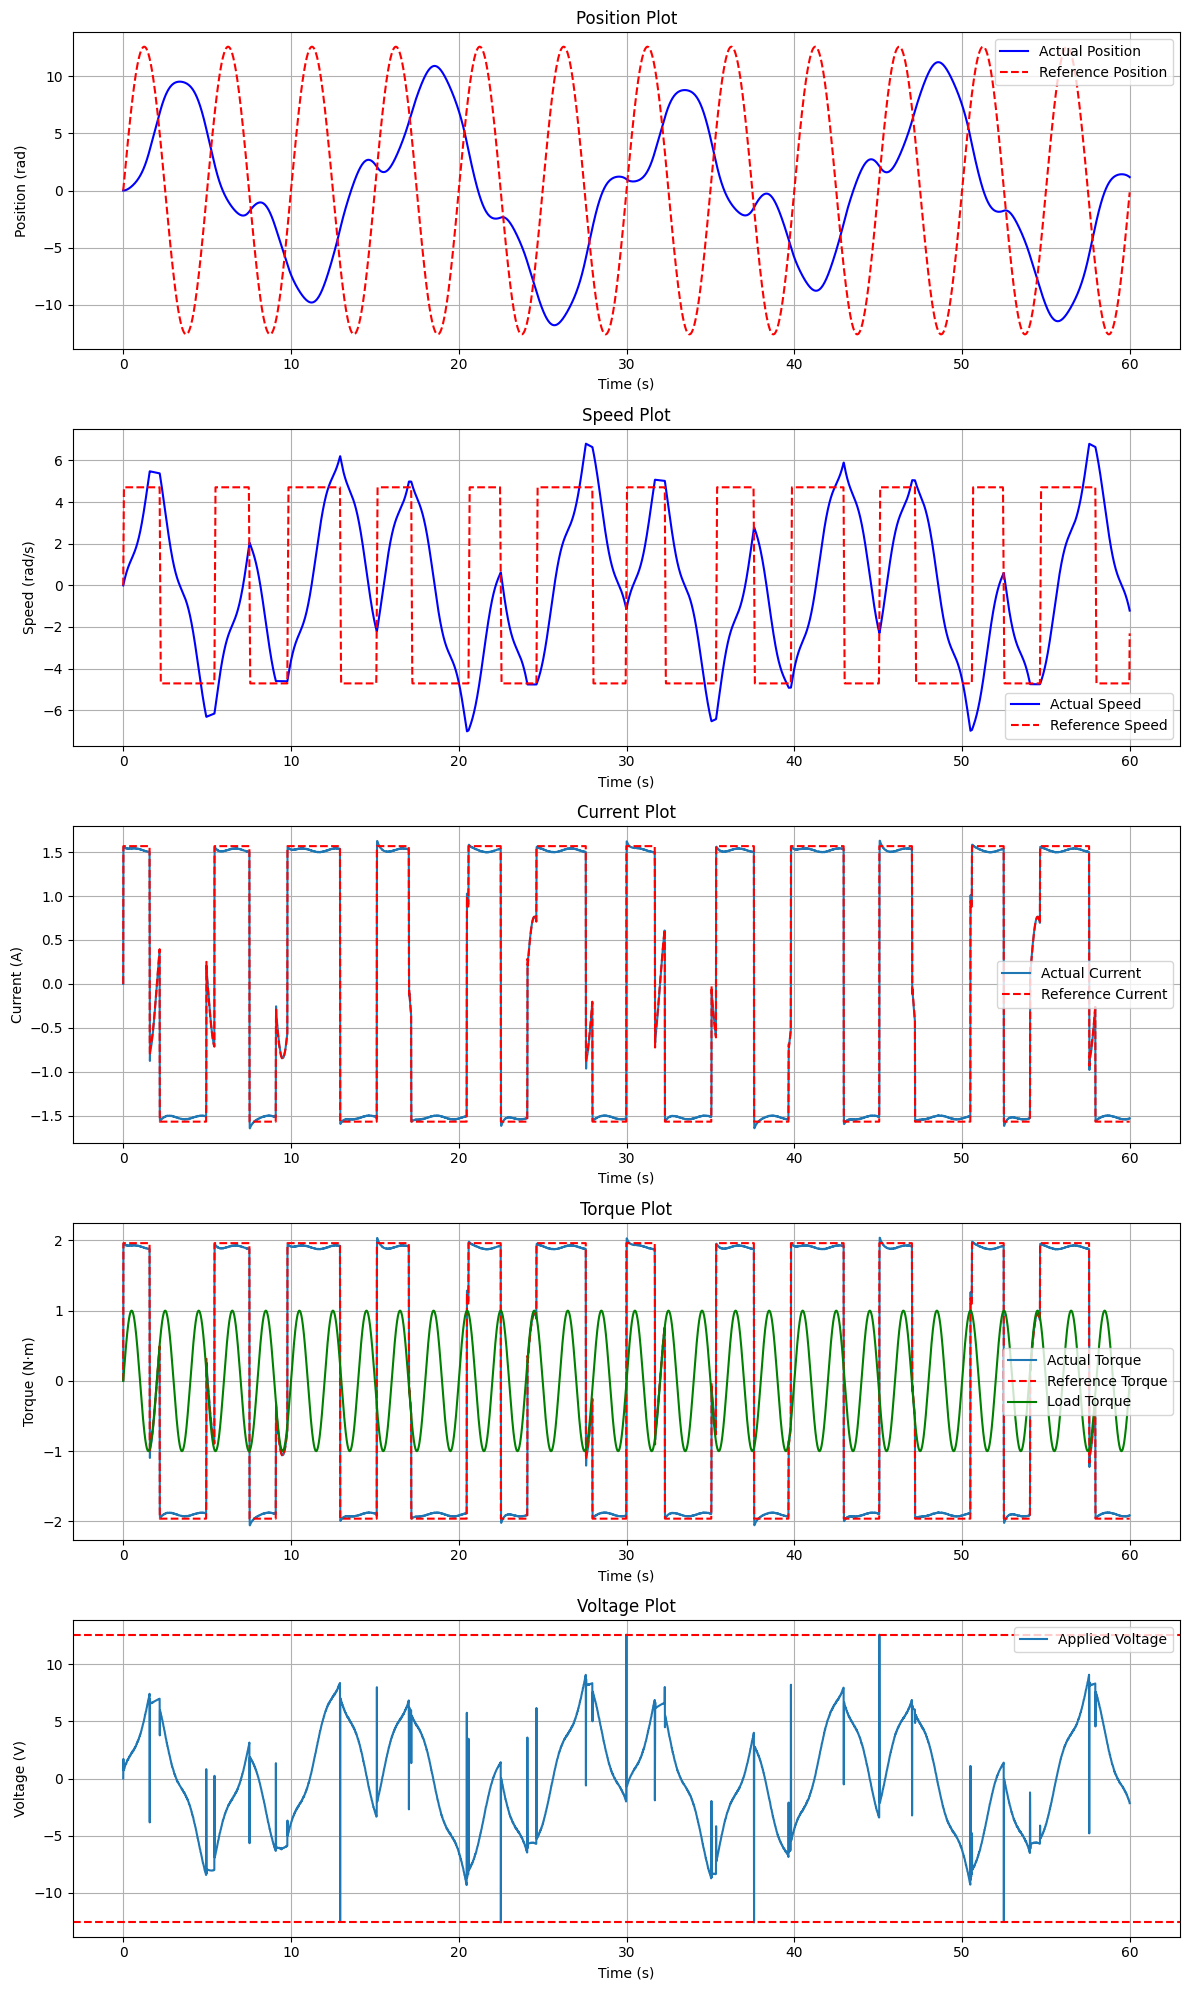

In [ ]:
#considering the position and velocity for the torque calculations
#motor reference is waveshare ST3215 servo motor

import numpy as np
import matplotlib.pyplot as plt 
import scipy.integrate as solve_int

La = 0.05
Kt = 1.25
Jm = 0.5
Ra = 0.4
Kb = 1.25
Bf = 0.01

# PI gains
# Position loop
Kp_position = 7.2
Ki_position = 1.2

# Speed loop
Kp_speed = 100
Ki_speed = 20

# Current loop
Kp_current = 20
Ki_current = 100

# Time
startTime = 0
endTime = 60
dt = 0.01
t_eval = np.arange(startTime,endTime,dt)

# Limits
V_max = 12.6
V_min = 6

T_max = 1.961
Omega_max = 4.712

# Position reference
Theta_amp = 360 * 2* np.pi / 180
Theta_freq = 0.2

Omega_amp = 3 * 2 * np.pi * Theta_freq
Omega_freq = 0.2

# Disturbance
load_amp = 1
load_freq = 0.5

# describing the motor plant
x0 = [0,0,0,0,0,0]

def motor_plant(t,x):

    theta = x[0]
    omega = x[1]
    current = x[2]
    integralError_current = x[3]
    integralError_omega = x[4]
    integralError_theta = x[5]

    #defining the load char
    Tload = load_amp*np.sin(2*np.pi*load_freq*t)

    #defining errors

    #position

    Theta_ref = Theta_amp*np.sin(
    2*np.pi*Theta_freq*t
)

    error_theta = Theta_ref - theta

    omega_ref = (
    Kp_position*error_theta
    + Ki_position*integralError_theta
)
    
    omega_ref = np.clip(
    omega_ref,
    -Omega_max,
    Omega_max
)
    
    error_omega = omega_ref - omega

    #speed 
    #this will change the required current
    Tref = (
    Kp_speed*error_omega
    + Ki_speed*integralError_omega
)

    Tref = np.clip(
    Tref,
    -T_max,
    T_max
)

    Iref = Tref/Kt

    error_current = Iref - current

    V_cmd = (
    Kp_current*error_current
    + Ki_current*integralError_current
)

    V_app = np.clip(
    V_cmd,
    -V_max,
    V_max
)

    dtheta = omega 

    domega = (
    Kt*current
    - Bf*omega
    - Tload
    )/Jm
    
    dcurrent = (
    V_app
    - Ra*current
    - Kb*omega
)/La
    
    dspeed_integral = error_omega
    dcurrent_integral = error_current
    dposition_integral = error_theta

    return [
        dtheta,
        domega,
        dcurrent,
        dcurrent_integral,
        dspeed_integral,
        dposition_integral
    ]

solution = solve_int.solve_ivp(
    motor_plant,
    (startTime, endTime),
    x0,
    t_eval=t_eval
)


def plot():

    Theta = solution.y[0]
    Omega = solution.y[1]
    Current = solution.y[2]

    current_integral = solution.y[3]
    speed_integral = solution.y[4]
    position_integral = solution.y[5]

    Theta_ref = Theta_amp*np.sin(
        2*np.pi*Theta_freq*solution.t
    )

    Load_comp = load_amp*np.sin(
        2*np.pi*load_freq*solution.t
    )


    error_theta = Theta_ref - Theta

    Omega_ref = (
        Kp_position*error_theta
        + Ki_position*position_integral
    )

    Omega_ref = np.clip(
        Omega_ref,
        -Omega_max,
        Omega_max
    )

    error_omega = Omega_ref - Omega

    Tref = (
        Kp_speed*error_omega
        + Ki_speed*speed_integral
    )

    Tref = np.clip(
        Tref,
        -T_max,
        T_max
    )


    Iref = Tref / Kt

    Torque_actual = Kt*Current

    V_cmd = (
        Kp_current*(Iref - Current)
        + Ki_current*current_integral
    )

    V_app = np.clip(
        V_cmd,
        -V_max,
        V_max
    )

    fig, ax = plt.subplots(
        5,1,
        figsize=(12,20)
    )

    ax[0].plot(
        solution.t,
        Theta,
        'b',
        label='Actual Position'
    )

    ax[0].plot(
        solution.t,
        Theta_ref,
        'r--',
        label='Reference Position'
    )

    ax[0].set_title("Position Plot")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Position (rad)")
    ax[0].legend()
    ax[0].grid()


    ax[1].plot(
        solution.t,
        Omega,
        'b',
        label='Actual Speed'
    )

    ax[1].plot(
        solution.t,
        Omega_ref,
        'r--',
        label='Reference Speed'
    )

    ax[1].set_title("Speed Plot")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Speed (rad/s)")

    ax[1].legend()
    ax[1].grid()



    ax[2].plot(
        solution.t,
        Current,
        label="Actual Current"
    )

    ax[2].plot(
        solution.t,
        Iref,
        'r--',
        label="Reference Current"
    )

    ax[2].set_title("Current Plot")
    ax[2].set_ylabel("Current (A)")
    ax[2].set_xlabel("Time (s)")
    ax[2].legend()
    ax[2].grid()



    ax[3].plot(
        solution.t,
        Torque_actual,
        label="Actual Torque"
    )

    ax[3].plot(
        solution.t,
        Tref,
        'r--',
        label="Reference Torque"
    )

    ax[3].plot(
        solution.t,
        Load_comp,
        'g',
        label="Load Torque"
    )

    ax[3].set_title("Torque Plot")
    ax[3].set_ylabel("Torque (N·m)")
    ax[3].set_xlabel("Time (s)")
    ax[3].legend()
    ax[3].grid()


    ax[4].plot(
        solution.t,
        V_app,
        label="Applied Voltage"
    )

    ax[4].axhline(
        V_max,
        linestyle='--',
        color='r'
    )

    ax[4].axhline(
        -V_max,
        linestyle='--',
        color='r'
    )

    ax[4].set_title("Voltage Plot")
    ax[4].set_ylabel("Voltage (V)")
    ax[4].set_xlabel("Time (s)")
    ax[4].legend()
    ax[4].grid()

    plt.tight_layout()
    plt.show()


print("The following result is obtained when  : \n")
print("Desired Position : amp. = {:.2f} rad, freq = {}\n".format(Theta_amp,Theta_freq)) 
print(f"Load : amp. = {load_amp} N.m, ferq = {load_freq}\n")
print(f"Desired Omega : amp. = {Omega_amp:.2f} rad/s, frq. = {Omega_freq}\n\n\n")

plot()



In [11]:
import numpy as np
import matplotlib.pyplot as plt 
import scipy.integrate as solve_int

La = 0.05
Kt = 1.25
Jm = 0.5
Ra = 0.4
Kb = 1.25
Bf = 0.01

# Limits
V_max = 12.6
T_max = 1.961
Omega_max = 4.712

# Time
startTime = 0
endTime = 10
dt = 0.01
t_eval = np.arange(startTime,endTime,dt)

# References

Theta_amp = 10
Theta_freq = 0.2

Omega_amp = 10 * 2 * np.pi * Theta_freq
Omega_freq = 0.2

# Disturbance

load_amp = 1
load_freq = 0.5

# Step 1 : Evaluate the net torque using integration
# Step 2 : Use the derived torque to control current and voltage to get the desired position and velocity -> desired torque

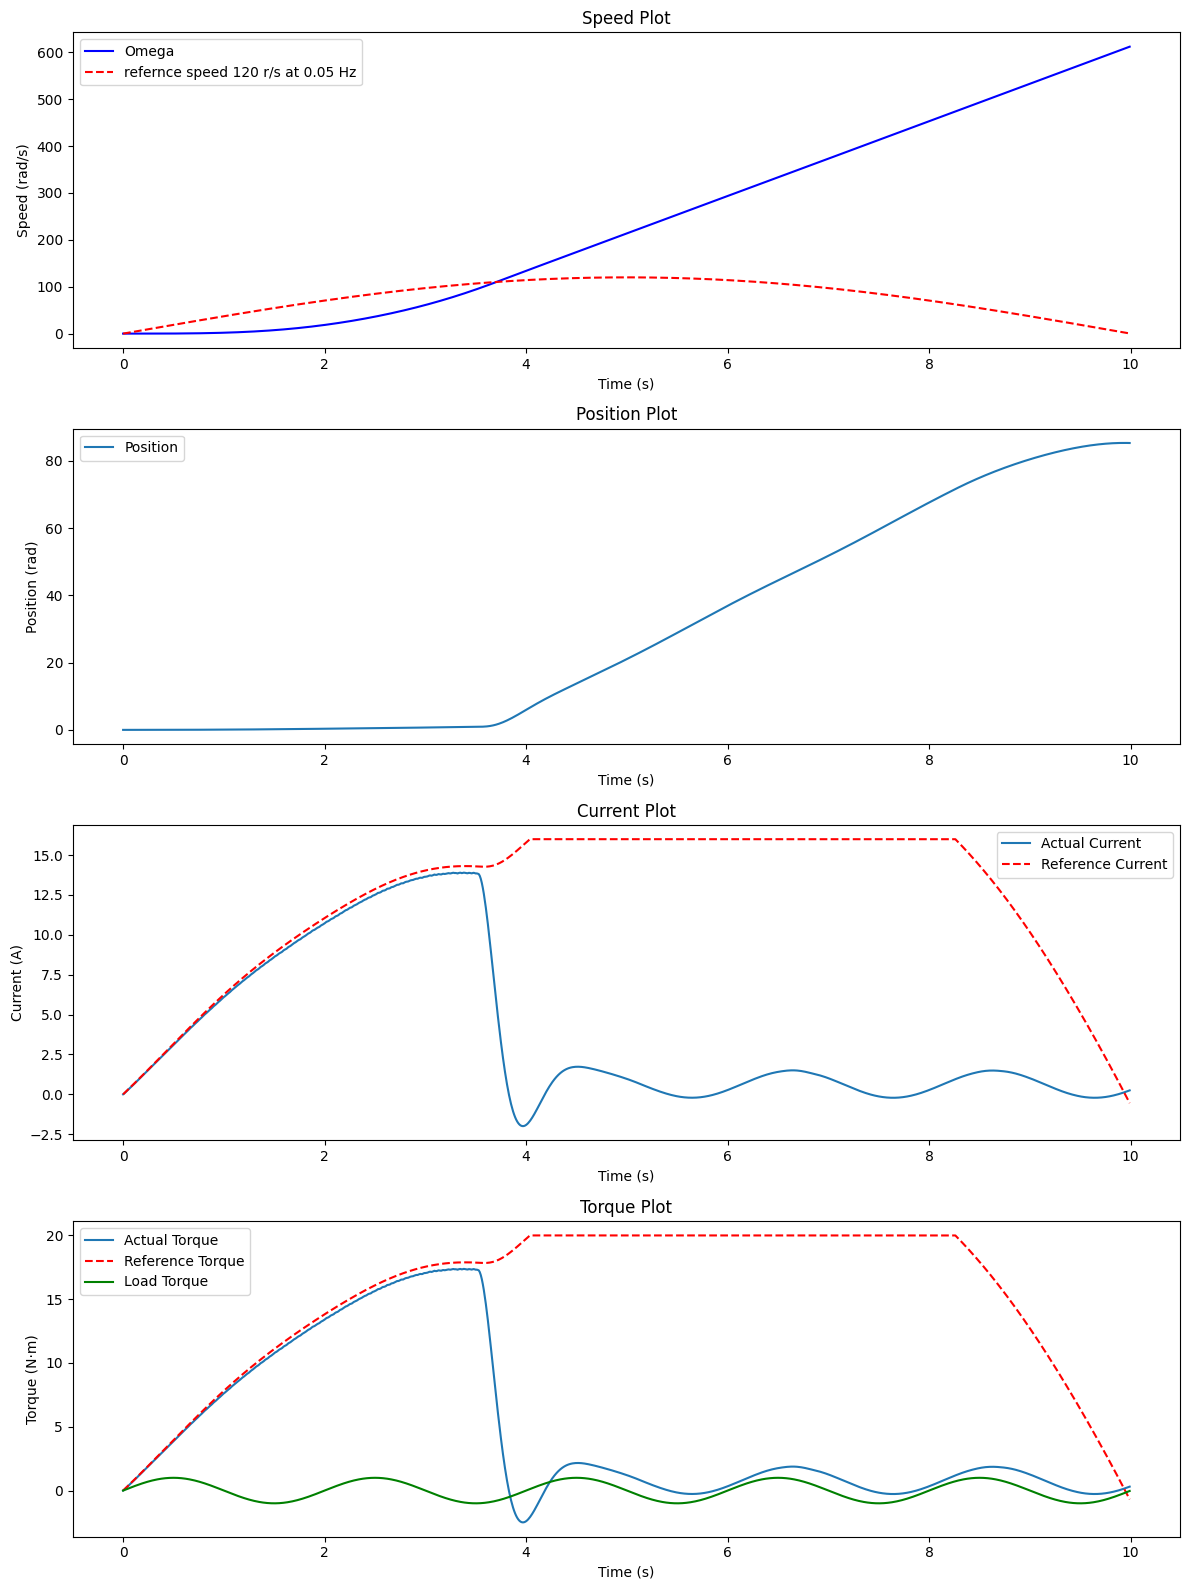

In [8]:
#Torque Control with speed and current controllers

#Motor dynamics must be changed 

import numpy as np
import matplotlib.pyplot as plt 
import scipy.integrate as solve_int

La = 0.05
Kt = 1.25
Jm = 0.5
Ra = 0.4
Kb = 1.25
Bf = 0.01

#PI gains
Kp = 100
Ki = 20

Kp_torque = 0.2
Ki_torque = 0.1

Kp_current = 20
Ki_current = 100

#time req.
startTime = 0
endTime = 10
dt = 0.01
t_eval = np.arange(startTime,endTime,dt)

#ref 
# V_max = 380
# T_max = 500

# Wref_amp = 150
# Wref_freq = 0.2

# load_amp = 2
# load_freq = 1.2

V_max = 100
T_max = 20

Wref_amp = 120
Wref_freq = 0.05

load_amp = 1
load_freq = 0.5

Tref_amp = 5
Tref_freq = 1

#describing the motor plant
x0 = [0,0,0,0,0]
def motor_plant(t,x):
    thetha = x[0]
    omega = x[1]
    current = x[2]
    integralError_current = x[3]
    integralError_omega = x[4]

    #defining the load char
    Tload = load_amp*np.sin(2*np.pi*load_freq*t)

    #defining errors
 
    #speed 
    #this will change the required current 

    Wref_profile = Wref_amp*np.sin(2*np.pi*Wref_freq*t)

    error_omega = Wref_profile - omega

    Tref_profile = (
    Kp_torque * error_omega
    + Ki_torque * integralError_omega
)
    Tref = np.clip(Tref_profile,-T_max,T_max)

    Iref = Tref / Kt


    #current 
    #this will change the required voltage 

    error_current = Iref - current
    V_cmd = (
    Kp_current * error_current
    + Ki_current * integralError_current
)

    V_app = np.clip(V_cmd, -V_max,V_max)

    dtheta = omega 

    domega = (
    Kt*current
    - Bf*omega
    - Tload
    )/Jm
    
    dcurrent = (
    V_app
    - Ra*current
    - Kb*omega
)/La
    
    dspeed_integral = error_omega
    dcurrent_integral = error_current

    return [
        dtheta,
        domega,
        dcurrent,
        dcurrent_integral,
        dspeed_integral
    ]


solution = solve_int.solve_ivp(
    motor_plant,
    (startTime,endTime),
    x0,
    t_eval=t_eval
)


##Chatgpt :


Omega = solution.y[1]
Current = solution.y[2]

W_comp = Wref_amp*np.sin(
    2*np.pi*Wref_freq*solution.t
)

Load_comp = load_amp*np.sin(
    2*np.pi*load_freq*solution.t
)

# Recompute controller outputs
error_omega = W_comp - Omega

speed_integral = solution.y[4]

Tref = (
    Kp_torque*error_omega
    + Ki_torque*speed_integral
)

Tref = np.clip(Tref, -T_max, T_max)

Iref = Tref / Kt

Torque_actual = Kt * Current

#-----------------


fig ,ax = plt.subplots(4,1,figsize=(12,16))

ax[0].plot(solution.t, solution.y[0],'b', label="Omega")
ax[0].plot(solution.t,W_comp,'r--', label="refernce speed {} r/s at {} Hz".format(Wref_amp,Wref_freq))
ax[0].set_title("Speed Plot")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Speed (rad/s)')
ax[0].legend()

ax[1].plot(solution.t, solution.y[3],label="Position")
ax[1].set_title("Position Plot")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Position (rad)')
ax[1].legend()

ax[2].plot(solution.t, Current, label="Actual Current")
ax[2].plot(solution.t, Iref, 'r--', label="Reference Current")
ax[2].set_title("Current Plot")
ax[2].set_ylabel("Current (A)")
ax[2].set_xlabel("Time (s)")
ax[2].legend()

ax[3].plot(solution.t, Torque_actual, label="Actual Torque")
ax[3].plot(solution.t, Tref, 'r--', label="Reference Torque")
ax[3].plot(solution.t, Load_comp, 'g', label="Load Torque")
ax[3].set_title("Torque Plot")
ax[3].set_ylabel("Torque (N·m)")
ax[3].set_xlabel("Time (s)")
ax[3].legend()

plt.tight_layout()
plt.show()

Simulation steps processed: 1000


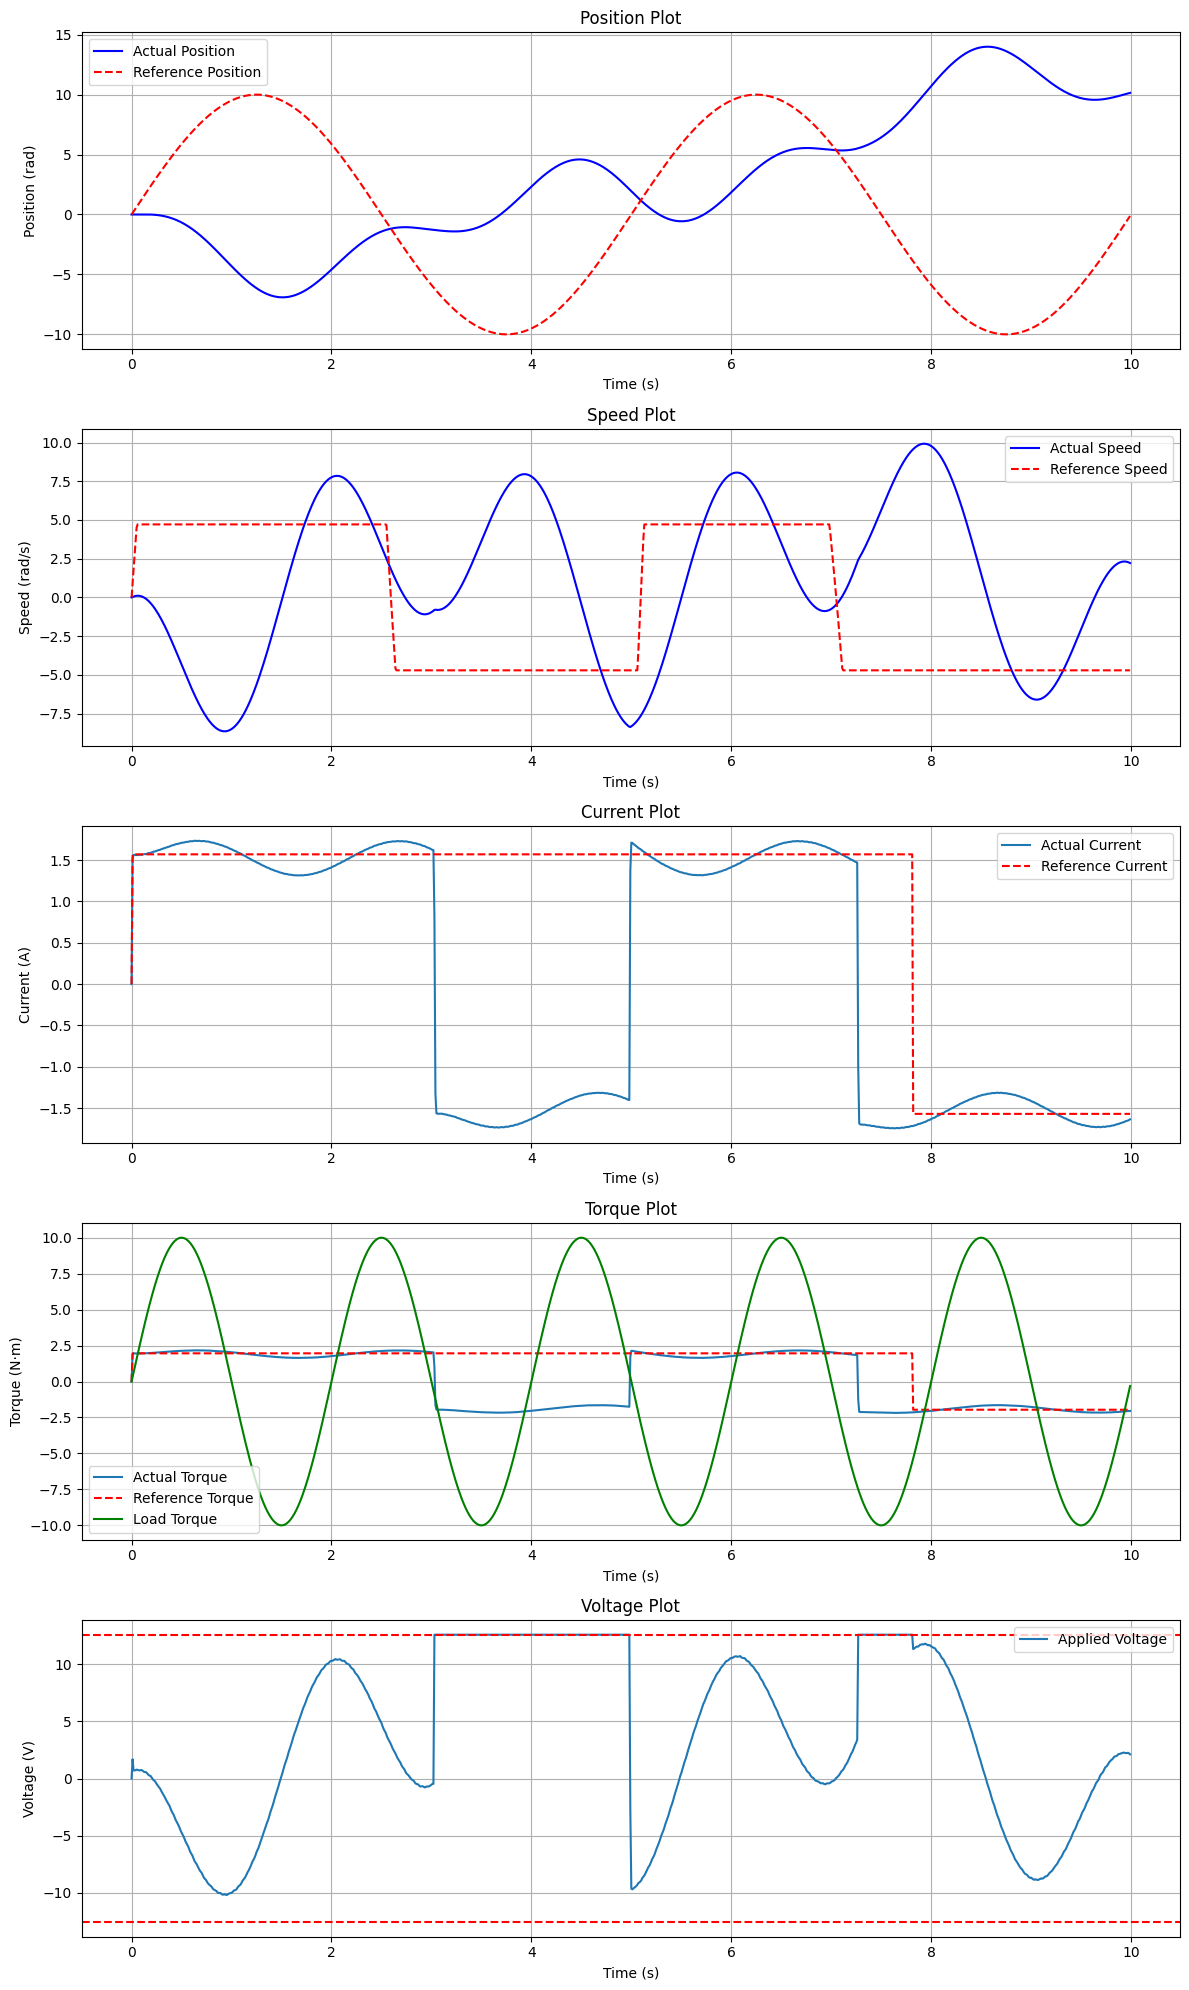

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as solve_int

# Motor Plant Constants
La = 0.05
Kt = 1.25
Jm = 0.5
Ra = 0.4
Kb = 1.25
Bf = 0.01

# --- Modified Controller Gains ---
# Outer Position Loop: ONLY Proportional (P) to match cascaded formulation
Kp_position = 7.2 

# Inner Velocity Loop: Proportional-Integral (PI)
Kp_speed = 100
Ki_speed = 20

# Innermost Current Loop: Proportional-Integral (PI)
Kp_current = 20
Ki_current = 100

# Time Settings
startTime = 0
endTime = 10
dt = 0.01
t_eval = np.arange(startTime, endTime, dt)

# Saturation Limits
V_max = 12.6
T_max = 1.961
Omega_max = 4.712

# Trajectory Settings
Theta_amp = 10
Theta_freq = 0.2

# Disturbance Load
load_amp = 10
load_freq = 0.5

# Initial States: [theta, omega, current, integralError_current, integralError_omega]
# Note: Position integral state removed as the outer loop is now pure P-control
x0 = [0, 0, 0, 0, 0]

def motor_plant(t, x):
    theta = x[0]
    omega = x[1]
    current = x[2]
    integralError_current = x[3]
    integralError_omega = x[4]
    
    # 1. External Disturbance
    Tload = load_amp * np.sin(2 * np.pi * load_freq * t)
    
    # 2. Outer Position Loop (Pure P Control)
    Theta_ref = Theta_amp * np.sin(2 * np.pi * Theta_freq * t)
    error_theta = Theta_ref - theta
    
    # Produces the target Velocity command
    omega_ref = Kp_position * error_theta
    omega_ref = np.clip(omega_ref, -Omega_max, Omega_max)
    
    # 3. Inner Velocity Loop (PI Control -> Produces Torque Reference)
    error_omega = omega_ref - omega
    Tref = (Kp_speed * error_omega) + (Ki_speed * integralError_omega)
    Tref = np.clip(Tref, -T_max, T_max)
    
    # 4. Innermost Current Loop (PI Control -> Produces Voltage Reference)
    Iref = Tref / Kt
    error_current = Iref - current
    V_cmd = (Kp_current * error_current) + (Ki_current * integralError_current)
    V_app = np.clip(V_cmd, -V_max, V_max)
    
    # 5. Plant Physics / State Derivatives
    dtheta = omega
    domega = (Kt * current - Bf * omega - Tload) / Jm
    dcurrent = (V_app - Ra * current - Kb * omega) / La
    
    # Integrator State Derivatives
    dspeed_integral = error_omega
    dcurrent_integral = error_current
    
    return [dtheta, domega, dcurrent, dcurrent_integral, dspeed_integral]

# Run Simulation
solution = solve_int.solve_ivp(motor_plant, (startTime, endTime), x0, t_eval=t_eval)
print(f"Simulation steps processed: {len(solution.y[0])}")

def plot():
    Theta = solution.y[0]
    Omega = solution.y[1]
    Current = solution.y[2]
    current_integral = solution.y[3]
    speed_integral = solution.y[4]
    
    # Reconstruct variables for mapping
    Theta_ref = Theta_amp * np.sin(2 * np.pi * Theta_freq * solution.t)
    Load_comp = load_amp * np.sin(2 * np.pi * load_freq * solution.t)
    
    error_theta = Theta_ref - Theta
    Omega_ref = np.clip(Kp_position * error_theta, -Omega_max, Omega_max)
    
    error_omega = Omega_ref - Omega
    Tref = np.clip((Kp_speed * error_omega) + (Ki_speed * speed_integral), -T_max, T_max)
    
    Iref = Tref / Kt
    Torque_actual = Kt * Current
    
    V_cmd = (Kp_current * (Iref - Current)) + (Ki_current * current_integral)
    V_app = np.clip(V_cmd, -V_max, V_max)
    
    # Plotting routine
    fig, ax = plt.subplots(5, 1, figsize=(12, 20))
    
    ax[0].plot(solution.t, Theta, 'b', label='Actual Position')
    ax[0].plot(solution.t, Theta_ref, 'r--', label='Reference Position')
    ax[0].set_title("Position Plot")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Position (rad)")
    ax[0].legend()
    ax[0].grid()
    
    ax[1].plot(solution.t, Omega, 'b', label='Actual Speed')
    ax[1].plot(solution.t, Omega_ref, 'r--', label='Reference Speed')
    ax[1].set_title("Speed Plot")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Speed (rad/s)")
    ax[1].legend()
    ax[1].grid()
    
    ax[2].plot(solution.t, Current, label="Actual Current")
    ax[2].plot(solution.t, Iref, 'r--', label="Reference Current")
    ax[2].set_title("Current Plot")
    ax[2].set_ylabel("Current (A)")
    ax[2].set_xlabel("Time (s)")
    ax[2].legend()
    ax[2].grid()
    
    ax[3].plot(solution.t, Torque_actual, label="Actual Torque")
    ax[3].plot(solution.t, Tref, 'r--', label="Reference Torque")
    ax[3].plot(solution.t, Load_comp, 'g', label="Load Torque")
    ax[3].set_title("Torque Plot")
    ax[3].set_ylabel("Torque (N·m)")
    ax[3].set_xlabel("Time (s)")
    ax[3].legend()
    ax[3].grid()
    
    ax[4].plot(solution.t, V_app, label="Applied Voltage")
    ax[4].axhline(V_max, linestyle='--', color='r')
    ax[4].axhline(-V_max, linestyle='--', color='r')
    ax[4].set_title("Voltage Plot")
    ax[4].set_ylabel("Voltage (V)")
    ax[4].set_xlabel("Time (s)")
    ax[4].legend()
    ax[4].grid()
    
    plt.tight_layout()
    plt.show()

plot()
